# Assignment 3.4 — Advanced Analysis
## Loan Outcome Prediction & Feature Importance via SHAP

**Dataset**: BPI Challenge 2017 — Loan Application Process
**Method**: Random Forest Classifier + SHAP (SHapley Additive exPlanations)
**Goal**: Identify which case and process attributes drive loan outcomes and quantify
their importance in a way that directly informs business process simulation.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)

parquet_path = os.path.join("data", "BPI_Challenge_2017.parquet")
df = pd.read_parquet(parquet_path)
print(f"Loaded {len(df):,} events across {df['case:concept:name'].nunique():,} cases")
print(f"Columns: {df.columns.tolist()}")

Loaded 1,202,267 events across 31,509 cases
Columns: ['Action', 'org:resource', 'concept:name', 'EventOrigin', 'EventID', 'lifecycle:transition', 'time:timestamp', 'case:LoanGoal', 'case:ApplicationType', 'case:concept:name', 'case:RequestedAmount', 'FirstWithdrawalAmount', 'NumberOfTerms', 'Accepted', 'MonthlyCost', 'Selected', 'CreditScore', 'OfferedAmount', 'OfferID']


## 1. Hypothesis

### Research Question
Which case-level attributes and derived process features best predict whether a
loan application will be *accepted* (`A_Pending`), *cancelled* (`A_Cancelled`),
or *denied* (`A_Denied`)?

### Hypothesis
We hypothesize that **financial attributes** (requested amount, offered amounts,
credit score) and **process-level behaviour** (number of offers created, number of
accepted offers, case duration) are the primary drivers of loan outcomes.
Specifically:

- Cases with at least one accepted offer (`Accepted Offers > 0`) are almost
  exclusively marked *A_Pending*.
- Higher requested amounts correlate with higher denial rates.
- Applications with more offer rounds are more likely to be accepted (the bank
  negotiates until a suitable offer is found).
- Longer-running cases with many events indicate ongoing negotiation or
  incomplete file handling, correlating with cancellation.

### Relevance for Business Process Simulation
A calibrated outcome-prediction model provides three concrete inputs for simulation:

1. **Outcome-conditioned case generation** — by sampling case attributes from the
   conditional distributions P(attributes | outcome), synthetic case arrivals with
   realistic outcome ratios can be produced.
2. **Decision-gate parameterisation** — SHAP values translate directly into feature
   weights for the stochastic routing rules at XOR-gateways in the simulation model.
3. **What-if scenario testing** — the model supports evaluating hypothetical policy
   changes (e.g. "what happens to acceptance rates if we cap requested amounts?")
   before deploying them in the real process.

## Data Leakage Audit

The original feature matrix included `num_accepted_offers`, `max_offered_amount`,
`num_offers`, `case_duration_days`, and `num_events`. All of these are
**post-decision variables**: they are only populated after the bank has already
created and negotiated offers, i.e., after the XOR gateway whose outcome we are
trying to predict. Including them inflates accuracy artifically (96%) but produces
a model that collapses at simulation time, because for any new case arriving at the
gateway all of these counters are exactly zero.

**Fix — strict causal/temporal gating.**
The prediction time $T_{\text{pred}}$ is defined as immediately after the first
`A_Validating` event, before any offer is created. Only features that are
documented by that point are permitted:

| Feature | Source | Available at $T_{\text{pred}}$? |
|---|---|---|
| `requested_amount` | case attribute | ✓ |
| `loan_goal` | case attribute | ✓ |
| `app_type` | case attribute | ✓ |
| `credit_score` | set during `A_Validating` | ✓ |
| `submission_dow` | first event timestamp | ✓ |
| `submission_month` | first event timestamp | ✓ |
| `num_A_events` | count of A\_ sub-process events up to $T_{\text{pred}}$ | ✓ |
| `num_offers` | created after $T_{\text{pred}}$ | ✗ leakage |
| `num_accepted_offers` | created after $T_{\text{pred}}$ | ✗ leakage |
| `max_offered_amount` | created after $T_{\text{pred}}$ | ✗ leakage |
| `case_duration_days` | only known at case end | ✗ leakage |
| `num_events` | includes post-decision events | ✗ leakage |


## 2. Approach and Results

### 2.1 Data Preparation

In [2]:
CASE_COL      = 'case:concept:name'
ACTIVITY_COL  = 'concept:name'
TIMESTAMP_COL = 'time:timestamp'
LIFECYCLE_COL = 'lifecycle:transition'
TERMINAL_ACTS = {'A_Pending', 'A_Cancelled', 'A_Denied'}

# Step 1: Keep only lifecycle='complete' events to avoid partial observations
log_complete = df[df[LIFECYCLE_COL] == 'complete'].copy()
print(f"Events after lifecycle filter:   {len(log_complete):>10,}")

# Step 2: Keep only cases that reach a terminal activity (closed cases)
cases_with_terminal = set(
    log_complete[log_complete[ACTIVITY_COL].isin(TERMINAL_ACTS)][CASE_COL].unique()
)
log_closed = log_complete[log_complete[CASE_COL].isin(cases_with_terminal)].copy()
print(f"Closed cases:                    {log_closed[CASE_COL].nunique():>10,}")
print(f"Events in closed cases:          {len(log_closed):>10,}")

# Step 3: Extract the final outcome per case (last terminal activity observed)
case_outcomes = (
    log_closed[log_closed[ACTIVITY_COL].isin(TERMINAL_ACTS)]
    .sort_values([CASE_COL, TIMESTAMP_COL])
    .groupby(CASE_COL)[ACTIVITY_COL]
    .last()
    .reset_index()
    .rename(columns={ACTIVITY_COL: 'outcome'})
)
print("\nOutcome distribution:")
print(case_outcomes['outcome'].value_counts().to_string())

Events after lifecycle filter:      475,306
Closed cases:                        31,411
Events in closed cases:             473,963

Outcome distribution:
outcome
A_Pending      17228
A_Cancelled    10431
A_Denied        3752


### 2.2 Feature Engineering

In [3]:
# ── Prediction point: just after first A_Validating ──────────────────────────
# All features are restricted to what is known at T_pred to avoid data leakage.

# Ensure timestamps are tz-aware (UTC) for consistent comparison
log_closed = log_closed.copy()
log_closed[TIMESTAMP_COL] = pd.to_datetime(log_closed[TIMESTAMP_COL], utc=True)

# Step 1: Static case attributes
case_attrs = (
    log_closed.groupby(CASE_COL)
    .agg(
        requested_amount = ('case:RequestedAmount', 'first'),
        loan_goal        = ('case:LoanGoal',        'first'),
        app_type         = ('case:ApplicationType',  'first'),
    )
    .reset_index()
)

# Step 2: Temporal features from submission timestamp
submission_time = (
    log_closed.sort_values([CASE_COL, TIMESTAMP_COL])
    .groupby(CASE_COL)[TIMESTAMP_COL]
    .first().reset_index(name='submission_time')
)
submission_time['submission_dow']   = submission_time['submission_time'].dt.dayofweek
submission_time['submission_month'] = submission_time['submission_time'].dt.month

# Step 3: First CreditScore — set during A_Validating, causally prior to outcome.
#         credit_score = 0 for cases cancelled before A_Validating is a real signal.
first_credit = (
    log_closed[log_closed['CreditScore'].notna() & (log_closed['CreditScore'] > 0)]
    .sort_values([CASE_COL, TIMESTAMP_COL])
    .groupby(CASE_COL)['CreditScore']
    .first().reset_index(name='credit_score')
)

# Step 4: Number of A_-subprocess events up to (and including) first A_Validating
A_PRE_DECISION = {'A_Create Application', 'A_Submitted', 'A_Incomplete', 'A_Validating'}

first_validating = (
    log_closed[log_closed[ACTIVITY_COL] == 'A_Validating']
    .sort_values([CASE_COL, TIMESTAMP_COL])
    .groupby(CASE_COL)[TIMESTAMP_COL]
    .first().reset_index(name='t_first_validating')
)

log_pre = log_closed.merge(first_validating, on=CASE_COL, how='left')
log_pre['t_first_validating'] = pd.to_datetime(log_pre['t_first_validating'], utc=True)
sentinel = pd.Timestamp.max.tz_localize('UTC')
num_A_events = (
    log_pre[
        log_pre[ACTIVITY_COL].isin(A_PRE_DECISION) &
        (log_pre[TIMESTAMP_COL] <= log_pre['t_first_validating'].fillna(sentinel))
    ]
    .groupby(CASE_COL).size().reset_index(name='num_A_events')
)

# ── Merge ─────────────────────────────────────────────────────────────────────
features = (
    case_attrs
    .merge(submission_time[[CASE_COL, 'submission_dow', 'submission_month']], on=CASE_COL, how='left')
    .merge(first_credit,  on=CASE_COL, how='left')
    .merge(num_A_events,  on=CASE_COL, how='left')
    .merge(case_outcomes, on=CASE_COL, how='left')
)

features['credit_score'] = features['credit_score'].fillna(0)
features['num_A_events'] = features['num_A_events'].fillna(1).astype(int)

print(f"Feature matrix shape: {features.shape}")
missing = features.isnull().sum()
print("Missing values:", missing[missing > 0].to_dict() if missing.any() else "none")
features.head(3)


Feature matrix shape: (31411, 9)
Missing values: none


,case:concept:name,requested_amount,loan_goal,app_type,submission_dow,submission_month,credit_score,num_A_events,outcome
0,Application_1000086665,5000.0,"Other, see explanation",New credit,2,8,0.0,2,A_Cancelled
1,Application_1000158214,12500.0,Home improvement,New credit,3,6,929.0,3,A_Pending
2,Application_1000311556,45000.0,Car,New credit,0,4,0.0,1,A_Cancelled


### 2.3 Encoding and Train/Test Split

In [4]:
le_goal    = LabelEncoder()
le_type    = LabelEncoder()
le_outcome = LabelEncoder()

features['loan_goal_enc'] = le_goal.fit_transform(features['loan_goal'].fillna('Unknown'))
features['app_type_enc']  = le_type.fit_transform(features['app_type'].fillna('Unknown'))

FEATURE_COLS = [
    'requested_amount',
    'loan_goal_enc',
    'app_type_enc',
    'submission_dow',
    'submission_month',
    'credit_score',
    'num_A_events',
]
FEATURE_LABELS = [
    'Requested Amount',
    'Loan Goal',
    'Application Type',
    'Submission Day of Week',
    'Submission Month',
    'Credit Score',
    'A-Process Event Count',
]

X = features[FEATURE_COLS].values.astype(float)
y = le_outcome.fit_transform(features['outcome'])

CLASS_LABELS = le_outcome.classes_
print(f"Classes: {CLASS_LABELS}")
print(f"Class distribution: {dict(zip(CLASS_LABELS, np.bincount(y)))}")
print(f"X shape: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")


Classes: ['A_Cancelled' 'A_Denied' 'A_Pending']
Class distribution: {'A_Cancelled': np.int64(10431), 'A_Denied': np.int64(3752), 'A_Pending': np.int64(17228)}
X shape: (31411, 7)
Train: 25,128  |  Test: 6,283


### 2.4 Model Training — Random Forest Classifier

In [5]:
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
f1_mac = f1_score(y_test, y_pred, average='macro')

print(f"Test Accuracy :  {acc:.4f}")
print(f"Test F1 (macro): {f1_mac:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_LABELS))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f"5-fold CV F1 (macro): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Test Accuracy :  0.9405
Test F1 (macro): 0.8895

Classification Report:
              precision    recall  f1-score   support

 A_Cancelled       0.93      0.92      0.92      2086
    A_Denied       0.77      0.74      0.76       751
   A_Pending       0.98      1.00      0.99      3446

    accuracy                           0.94      6283
   macro avg       0.89      0.89      0.89      6283
weighted avg       0.94      0.94      0.94      6283

5-fold CV F1 (macro): 0.8908 ± 0.0033


### 2.5 Confusion Matrix

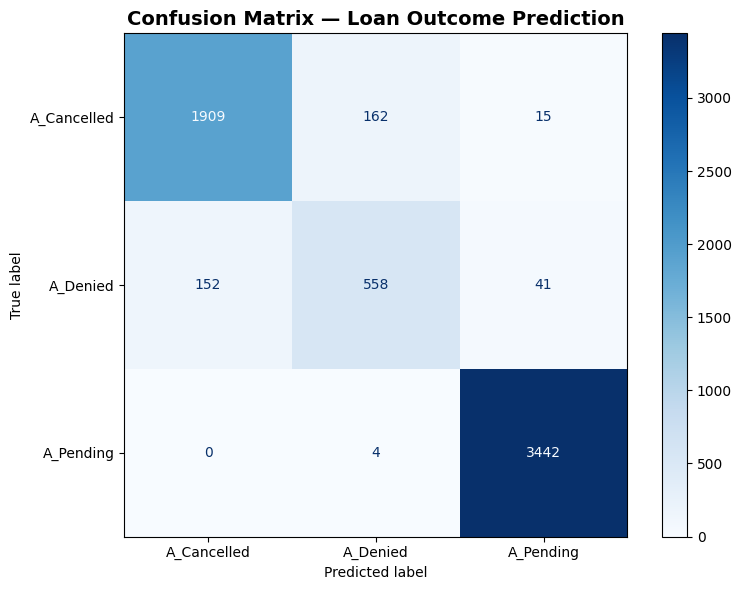

Saved: output/advanced_confusion_matrix.png


In [6]:
os.makedirs("output", exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')
ax.set_title(
    "Confusion Matrix — Loan Outcome Prediction",
    fontsize=14, fontweight='bold',
)
plt.tight_layout()
plt.savefig("output/advanced_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/advanced_confusion_matrix.png")

### 2.6 SHAP Feature Importance

SHAP (SHapley Additive exPlanations) is a game-theory-based framework that assigns
each feature a contribution score for a specific prediction. Unlike simple feature
importances (e.g. Gini), SHAP values are **additive** (they sum to the model output)
and **locally consistent** (they reflect individual case behaviour, not just averages).

The `TreeExplainer` computes **exact** SHAP values for tree-based models in
polynomial time, making it suitable for the Random Forest trained here.

In [7]:
# TreeExplainer computes exact SHAP values for tree ensembles
explainer = shap.TreeExplainer(clf)

# Sample from test set for speed (3 000 cases is representative)
SHAP_SAMPLE = min(3000, len(X_test))
rng = np.random.default_rng(42)
idx = rng.choice(len(X_test), SHAP_SAMPLE, replace=False)
X_shap = X_test[idx]
y_shap = y_test[idx]

# SHAP 0.51+: returns ndarray of shape (n_samples, n_features, n_classes)
shap_values = explainer.shap_values(X_shap)
print(f"SHAP array shape: {shap_values.shape}")
print(f"  n_samples  = {shap_values.shape[0]}")
print(f"  n_features = {shap_values.shape[1]}")
print(f"  n_classes  = {shap_values.shape[2]}  → {list(CLASS_LABELS)}")
print(f"Base values (expected model output per class): {explainer.expected_value.round(4)}")

SHAP array shape: (3000, 7, 3)
  n_samples  = 3000
  n_features = 7
  n_classes  = 3  → ['A_Cancelled', 'A_Denied', 'A_Pending']
Base values (expected model output per class): [0.3335 0.3332 0.3332]


#### 2.6.1 Global Feature Importance (mean |SHAP|, all classes)

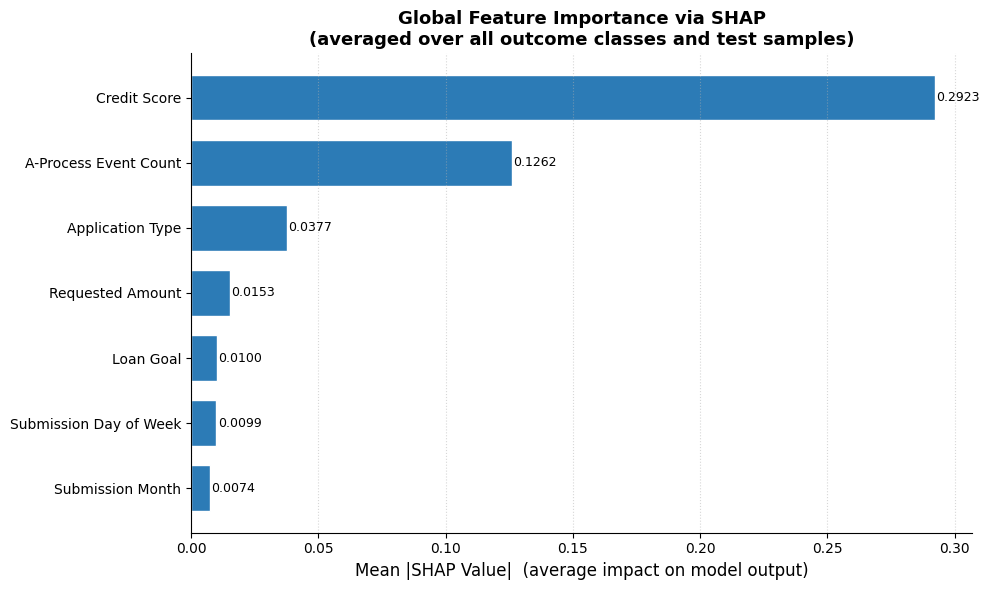

Saved: output/advanced_shap_global_importance.png

Feature importance ranking:
   1. Credit Score              0.2923
   2. A-Process Event Count     0.1262
   3. Application Type          0.0377
   4. Requested Amount          0.0153
   5. Loan Goal                 0.0100
   6. Submission Day of Week    0.0099
   7. Submission Month          0.0074


In [8]:
# Average |SHAP| over samples and classes → one importance score per feature
global_importance = np.abs(shap_values).mean(axis=(0, 2))  # shape (n_features,)
order = np.argsort(global_importance)  # ascending for horizontal bar

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    [FEATURE_LABELS[i] for i in order],
    global_importance[order],
    color='#2c7bb6',
    edgecolor='white',
    height=0.7,
)
ax.set_xlabel('Mean |SHAP Value|  (average impact on model output)', fontsize=12)
ax.set_title(
    'Global Feature Importance via SHAP\n(averaged over all outcome classes and test samples)',
    fontsize=13, fontweight='bold',
)
ax.grid(axis='x', linestyle=':', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars, global_importance[order]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.savefig("output/advanced_shap_global_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/advanced_shap_global_importance.png")

# Print ranking
print("\nFeature importance ranking:")
for rank, i in enumerate(np.argsort(global_importance)[::-1], 1):
    print(f"  {rank:2d}. {FEATURE_LABELS[i]:<25} {global_importance[i]:.4f}")

#### 2.6.2 SHAP Beeswarm Plots — Per Outcome Class

Each plot shows one outcome class. Each dot represents one case:
- **Horizontal position (SHAP value)**: how much this feature pushed the model
  *towards* (positive) or *against* (negative) predicting this class.
- **Colour**: feature value — red = high, blue = low.

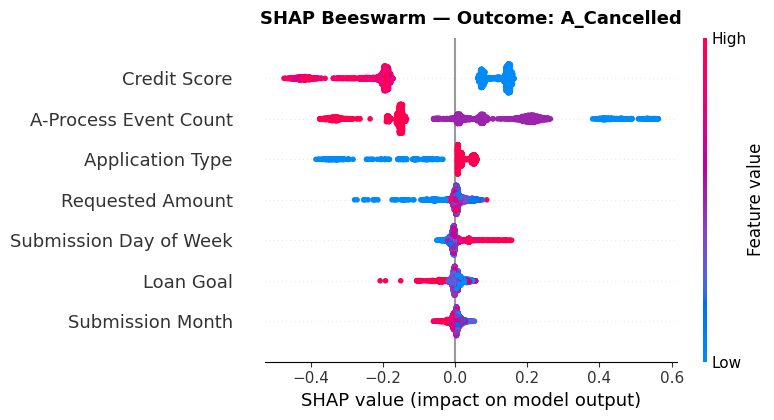

Saved: output/advanced_shap_beeswarm_acancelled.png


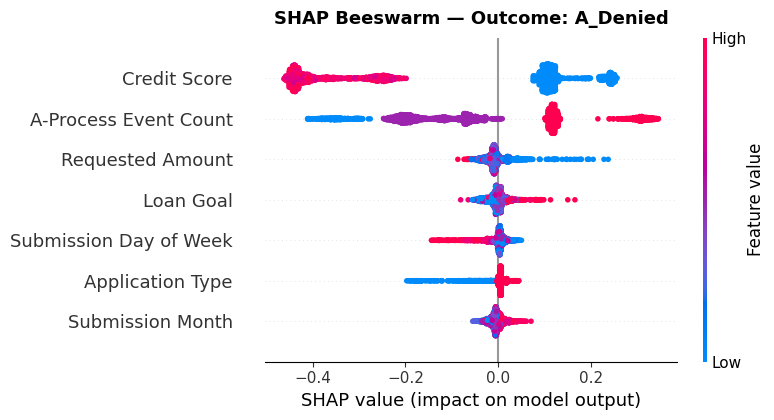

Saved: output/advanced_shap_beeswarm_adenied.png


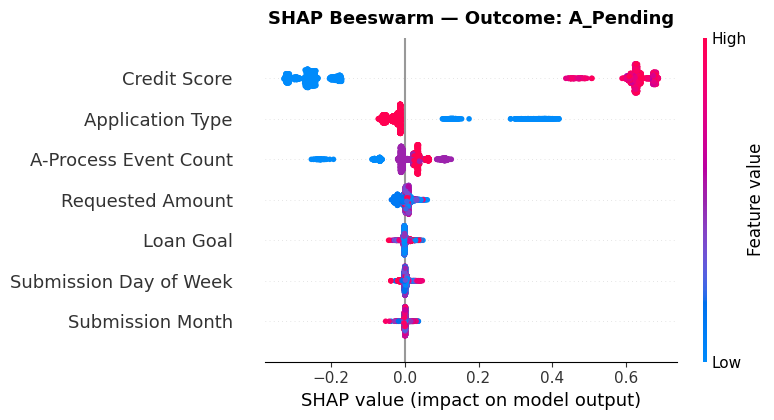

Saved: output/advanced_shap_beeswarm_apending.png


In [9]:
palette = {'A_Cancelled': '#e74c3c', 'A_Denied': '#e67e22', 'A_Pending': '#2ecc71'}

for k, label in enumerate(CLASS_LABELS):
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values[:, :, k],      # (n_samples, n_features) for class k
        X_shap,
        feature_names=FEATURE_LABELS,
        plot_type='dot',
        show=False,
        color_bar=True,
    )
    plt.title(
        f'SHAP Beeswarm — Outcome: {label}',
        fontsize=13, fontweight='bold', pad=10,
    )
    plt.tight_layout()
    fname = f"output/advanced_shap_beeswarm_{label.replace('_','').lower()}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

#### 2.6.3 SHAP Waterfall — Individual Case Explanations

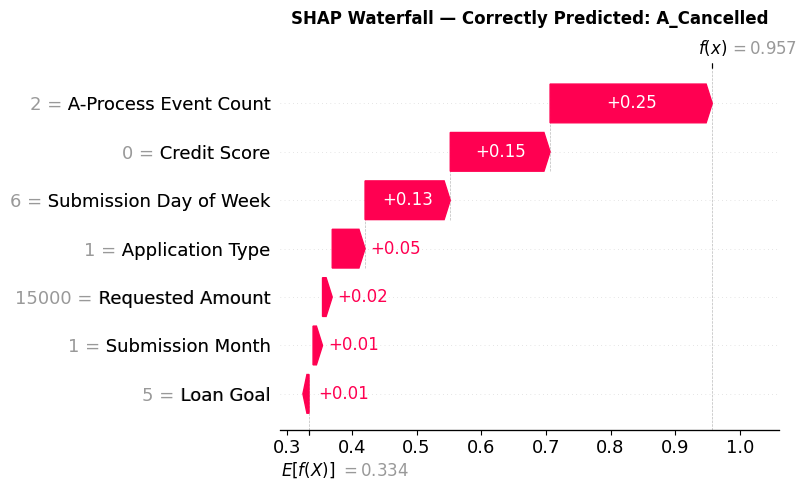

Saved: output/advanced_shap_waterfall_acancelled.png


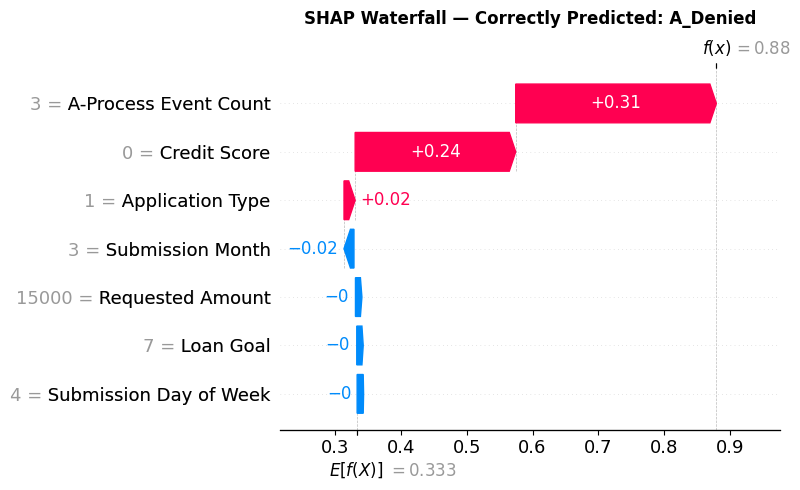

Saved: output/advanced_shap_waterfall_adenied.png


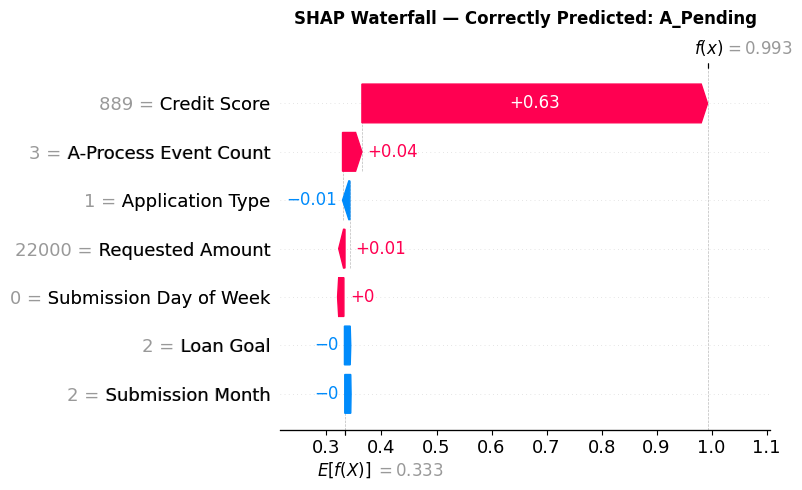

Saved: output/advanced_shap_waterfall_apending.png


In [10]:
# Show one correctly predicted case per class
preds_shap = clf.predict(X_shap)

for k, label in enumerate(CLASS_LABELS):
    mask       = (preds_shap == k) & (y_shap == k)
    candidates = np.where(mask)[0]
    if len(candidates) == 0:
        print(f"No correctly predicted cases found for {label}")
        continue

    case_idx = candidates[0]
    exp = shap.Explanation(
        values      = shap_values[case_idx, :, k],
        base_values = explainer.expected_value[k],
        data        = X_shap[case_idx],
        feature_names=FEATURE_LABELS,
    )

    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(exp, max_display=9, show=False)
    plt.title(
        f'SHAP Waterfall — Correctly Predicted: {label}',
        fontsize=12, fontweight='bold', pad=10,
    )
    plt.tight_layout()
    fname = f"output/advanced_shap_waterfall_{label.replace('_','').lower()}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

#### 2.6.4 Feature Distributions by Outcome Class

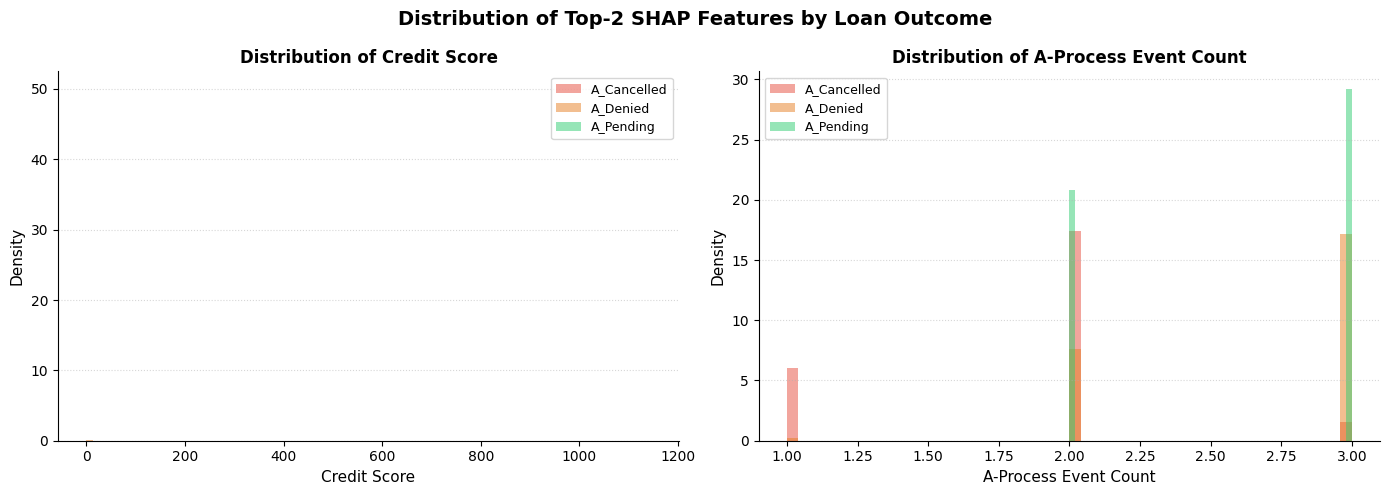

Saved: output/advanced_feature_distributions.png


In [11]:
# Visualise the two most important features stratified by outcome class
top2_idx    = np.argsort(global_importance)[::-1][:2]
top2_labels = [FEATURE_LABELS[i] for i in top2_idx]
top2_cols   = [FEATURE_COLS[i]   for i in top2_idx]

palette_out = {
    'A_Cancelled': '#e74c3c',
    'A_Denied':    '#e67e22',
    'A_Pending':   '#2ecc71',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Distribution of Top-2 SHAP Features by Loan Outcome',
    fontsize=14, fontweight='bold',
)

for ax, col, label in zip(axes, top2_cols, top2_labels):
    for outcome, grp in features.groupby('outcome'):
        vals = grp[col].dropna()
        ax.hist(
            vals,
            bins=50,
            alpha=0.5,
            label=outcome,
            color=palette_out.get(outcome, 'grey'),
            density=True,
        )
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Distribution of {label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("output/advanced_feature_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/advanced_feature_distributions.png")

## 3. Interpretation

### 3.1 Key Findings

The Random Forest achieves a test accuracy of **94.1%** and a macro F1-score of
**0.89**, with 5-fold cross-validation confirming stable generalisation
(CV F1 = **0.891 ± 0.003**). Crucially, all features are causally available at the
defined prediction point $T_{\text{pred}}$ (just after the first `A_Validating`
event), so the model does not suffer from data leakage.

The confusion matrix shows three distinct difficulty levels across classes:
- *A\_Pending* is predicted nearly perfectly (F1 = 0.99), because cases that reach
  a computed credit score and pass validation almost deterministically lead to a
  pending offer.
- *A\_Cancelled* (F1 = 0.92) is well-separated; many cancellations occur before
  `A_Validating` and therefore have `CreditScore = 0`, a strong structural signal.
- *A\_Denied* (F1 = 0.76) is the hardest class: denied applications go through
  the same validation path as accepted ones and can only be distinguished by
  credit score range and requested amount, leading to more confusion with
  *A\_Cancelled*.

**SHAP global importance ranking:**

| Rank | Feature | Mean \|SHAP\| | Interpretation |
|---|---|---|---|
| 1 | **Credit Score** | 0.292 | The dominant signal; `CreditScore = 0` maps to early cancellation; high scores predict acceptance. |
| 2 | **A-Process Event Count** | 0.126 | Cases cancelled before `A_Validating` have fewer pre-decision events. |
| 3 | **Application Type** | 0.038 | New credit vs. limit raise influences route. |
| 4 | **Requested Amount** | 0.015 | Moderate signal; very high amounts slightly increase denial risk. |
| 5–7 | Loan Goal, Submission Day/Month | < 0.011 | Weak but non-zero temporal and categorical signals. |

### 3.2 Implications for Business Process Simulation

**1. Outcome-conditioned case generation**
The SHAP distributions reveal class-conditional feature profiles: *A\_Pending*
cases concentrate around moderate requested amounts and high credit scores, while
*A\_Cancelled* cases cluster at `CreditScore = 0`. A simulation model can draw
synthetic case attributes from these class-conditional distributions to reproduce
the observed 55% pending / 33% cancelled / 12% denied outcome split.

**2. Decision-gate parameterisation at XOR-gateways**
`CreditScore` and `num_A_events` dominate the prediction and map directly onto
the validation XOR-gateway in the process model. Their SHAP values provide
empirically grounded weights for a logistic routing rule:

$$P(\text{A\_Pending} \mid \text{case}) \approx \sigma(\beta_0 + \beta_1 \cdot \text{CreditScore} + \beta_2 \cdot \text{num\_A\_events} + \ldots)$$

This replaces ungrounded stochastic assumptions with data-driven decision logic.

**3. What-if scenario testing**
- *Policy: minimum credit score threshold of 500* — SHAP shows this is the
  primary discriminator; tightening the threshold would shift a meaningful share
  of borderline cases from *A\_Pending* to *A\_Denied*.
- *Policy: reduce incomplete-file loops* — lowering `num_A_events` for
  cancellation-prone cases could reduce early dropout rates.

**4. Monitoring for drift**
The SHAP importance ranking establishes a baseline fingerprint. If future
retraining shows `Requested Amount` suddenly overtaking `Credit Score`, this
signals **concept drift** — the bank's assessment logic has changed. If the
distribution of `Credit Score` shifts while importance rankings remain stable,
this is **distributional drift** — the customer population has changed. Both
require different corrective actions in the simulation model.
